# 05. Compare 192-component mutational spectra

This notebook builds DB-weighted 192-component mutational spectra for groups prepared in `03_prepare_spectrum_groups_192.ipynb` and weighted in `04_add_spectrum_weights_192.ipynb`.

The input table is:

```text
../results/spectrum_groups/spectrum_groups_with_weights_192_T95.tsv
```

The key weight is:

```text
combined_db_spectrum_weight
```

It is calculated in the previous step as:

```text
combined_db_spectrum_weight =
    max(gnomAD_count + Helix_count, 1)
    /
    ((gnomAD_total + Helix_total) * ref_context_count)
```

Before opportunity counts are used here, all positions belonging to canonical MITOMAP loci marked `[on complement]` are reverse-complemented into their functional-strand orientation. `ref_context_count` is then recomputed from these strand-oriented circular contexts. Categories are not collapsed into six pyrimidine-centered classes: all 192 directional channels remain distinct. Original rCRS-oriented columns are retained with an `_rcrs` suffix for QC.

The strand-oriented weights are calculated once before spectrum aggregation. We then sum them by group and substitution type and divide all groups by one shared total weight.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("../scripts").resolve()))
from mutspec192_ci import (
    SBS192_REFERENCE_ORDER,
    estimate_shared_spectrum_uncertainty,
    plot_mutspec192_difference_with_ci,
    plot_mutspec192_with_ci,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

In [2]:
# ============================================================
# Paths and deterministic 192-component order
# ============================================================

INPUT_PATH = Path("../results/spectrum_groups/spectrum_groups_with_weights_192_T95.tsv")
MITOMAP_LOCI_INPUT = Path("../data/raw/mitomap/mitomap_genome_loci_192_r889.tsv")

OUTPUT_DIR = Path("../results/mutation_spectra")
FIGURE_DIR = Path("../results/figures/mutation_spectra_192_T95")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SPECTRUM_OUTPUT = OUTPUT_DIR / "spectrum_weighted_frequencies_192_T95.tsv"
UNCERTAINTY_OUTPUT = OUTPUT_DIR / "spectrum_uncertainty_192_T95.tsv"
DIFFERENCE_UNCERTAINTY_OUTPUT = (
    OUTPUT_DIR / "spectrum_difference_uncertainty_192_T95.tsv"
)
N_BOOTSTRAP_SIMULATIONS = 4000
BOOTSTRAP_RESAMPLING_METHOD = "position_bootstrap"
BOOTSTRAP_RANDOM_SEED = 20260810

WEIGHT_COL = "combined_db_spectrum_weight"
GROUP_COL = "spectrum_group_primary_T95"
GROUP_ORDER = [
    "expanded_neutral_like_T95",
    "unlabeled_out_of_neutral_domain_T95",
]
EXPECTED_COMPLEMENT_LOCI = {
    "MT-ND6", "MT-TQ", "MT-TA", "MT-TN", "MT-TC",
    "MT-TY", "MT-TS1", "MT-TE", "MT-TP",
}
DNA_COMPLEMENT = {"A": "T", "C": "G", "G": "C", "T": "A"}

substitution_order_12 = [
    "A>C", "A>G", "A>T",
    "C>A", "C>G", "C>T",
    "G>A", "G>C", "G>T",
    "T>A", "T>C", "T>G",
]
substitution_order_192 = [
    f"{left}[{substitution}]{right}"
    for left in "ACGT"
    for substitution in substitution_order_12
    for right in "ACGT"
]

assert len(substitution_order_192) == 192
assert len(set(substitution_order_192)) == 192

## Load spectrum-group table

At this stage each row is one possible mtDNA SNV. The table contains the group assignment from Isolation Forest and rCRS-oriented population counts from gnomAD + Helix. This notebook assigns canonical complement-strand positions from MITOMAP, reverse-complements their alleles and flanking context, and recomputes opportunity-normalized weights before any aggregation, QC ranking, or plotting.

In [3]:
df = pd.read_csv(INPUT_PATH, sep="\t", low_memory=False)
loci = pd.read_csv(MITOMAP_LOCI_INPUT, sep="\t")

required_cols = {
    "variant_id", "position", "reference", "alternate",
    "left_base", "right_base", "trinucleotide_context",
    "substitution_type_12", "substitution_type_192",
    "is_valid_snv_substitution", "combined_db_observed",
    "combined_db_count_raw", "combined_db_count_pc",
    "combined_db_total_records", "ref_context_count",
    "combined_db_spectrum_weight",
    "combined_db_spectrum_weight_raw", GROUP_COL,
}
missing_cols = sorted(required_cols.difference(df.columns))
if missing_cols:
    raise ValueError(f"Missing required 192-spectrum columns: {missing_cols}")

complement_loci = loci[loci["map_locus"].isin(EXPECTED_COMPLEMENT_LOCI)].copy()
observed_complement_loci = set(
    complement_loci.loc[
        complement_loci["description"].str.contains(
            "[on complement]", regex=False, na=False
        ),
        "map_locus",
    ]
)
if observed_complement_loci != EXPECTED_COMPLEMENT_LOCI:
    raise ValueError(
        f"Unexpected complement-strand loci: {sorted(observed_complement_loci)}"
    )

def expand_circular_interval(start, end, genome_length=16569):
    start = int(start)
    end = int(end)
    if start <= end:
        return range(start, end + 1)
    return list(range(start, genome_length + 1)) + list(range(1, end + 1))


complement_positions = set()
for row in complement_loci.itertuples(index=False):
    complement_positions.update(expand_circular_interval(row.start, row.end))

work = df[df["is_valid_snv_substitution"] == 1].copy()
rcrs_cols = [
    "reference", "alternate", "left_base", "right_base",
    "trinucleotide_context", "substitution_type_12",
    "substitution_type_192", "ref_context_count",
    "combined_db_spectrum_weight",
    "combined_db_spectrum_weight_raw",
]
for column in rcrs_cols:
    work[f"{column}_rcrs"] = work[column]

work["is_complement_strand"] = work["position"].isin(complement_positions)
complement_mask = work["is_complement_strand"]
work.loc[complement_mask, "left_base"] = (
    work.loc[complement_mask, "right_base_rcrs"].map(DNA_COMPLEMENT)
)
work.loc[complement_mask, "right_base"] = (
    work.loc[complement_mask, "left_base_rcrs"].map(DNA_COMPLEMENT)
)
work.loc[complement_mask, "reference"] = (
    work.loc[complement_mask, "reference_rcrs"].map(DNA_COMPLEMENT)
)
work.loc[complement_mask, "alternate"] = (
    work.loc[complement_mask, "alternate_rcrs"].map(DNA_COMPLEMENT)
)
work["trinucleotide_context"] = (
    work["left_base"] + work["reference"] + work["right_base"]
)
work["substitution_type_12"] = work["reference"] + ">" + work["alternate"]
work["substitution_type_192"] = (
    work["left_base"] + "[" + work["substitution_type_12"]
    + "]" + work["right_base"]
)

position_universe = (
    work[["position", "trinucleotide_context", "is_complement_strand"]]
    .drop_duplicates("position")
)
if len(position_universe) * 3 != len(work):
    raise ValueError("Expected exactly three alternate SNVs per position.")
context_counts = position_universe["trinucleotide_context"].value_counts()
work["ref_context_count"] = work["trinucleotide_context"].map(context_counts)

rcrs_position_universe = (
    work[["position", "trinucleotide_context_rcrs"]]
    .drop_duplicates("position")
)
rcrs_context_counts = (
    rcrs_position_universe["trinucleotide_context_rcrs"].value_counts()
)
if not np.array_equal(
    work["ref_context_count_rcrs"].to_numpy(),
    work["trinucleotide_context_rcrs"].map(rcrs_context_counts).to_numpy(),
):
    raise ValueError("rCRS context opportunities no longer match notebook 04.")

db_total = pd.to_numeric(work["combined_db_total_records"], errors="raise")
if db_total.nunique() != 1 or (db_total <= 0).any():
    raise ValueError("Expected one positive combined database denominator.")
work[WEIGHT_COL] = (
    work["combined_db_count_pc"] / (db_total * work["ref_context_count"])
)
work["combined_db_spectrum_weight_raw"] = (
    work["combined_db_count_raw"] / (db_total * work["ref_context_count"])
)

if int(position_universe["is_complement_strand"].sum()) != len(complement_positions):
    raise ValueError("Not every complement-strand position was oriented.")
if not work.loc[~complement_mask, "substitution_type_192"].equals(
    work.loc[~complement_mask, "substitution_type_192_rcrs"]
):
    raise ValueError("Reference-strand categories changed unexpectedly.")
nd6_position_14149 = work[work["position"] == 14149]
observed_nd6_categories = dict(zip(
    nd6_position_14149["alternate_rcrs"],
    nd6_position_14149["substitution_type_192"],
))
expected_nd6_categories = {
    "A": "G[G>T]T", "G": "G[G>C]T", "T": "G[G>A]T",
}
if observed_nd6_categories != expected_nd6_categories:
    raise ValueError(
        f"Unexpected strand-oriented ND6 example: {observed_nd6_categories}"
    )

work = work[work[GROUP_COL] != "exclude"].copy()

unknown_categories = sorted(
    set(work["substitution_type_192"].dropna()) - set(substitution_order_192)
)
if unknown_categories:
    raise ValueError(f"Unknown 192-component categories: {unknown_categories[:10]}")

print("Input shape:", df.shape)
print("Analysis table shape:", work.shape)
print("Complement-strand loci:", sorted(observed_complement_loci))
print("Reverse-complemented positions:", len(complement_positions))
print("Categories represented:", work["substitution_type_192"].nunique(), "/ 192")
print("\nGroups:")
print(work[GROUP_COL].value_counts(dropna=False))
print("\nWeight summary:")
print(work[WEIGHT_COL].describe())

Input shape: (49698, 60)
Analysis table shape: (49558, 71)
Complement-strand loci: ['MT-ND6', 'MT-TA', 'MT-TC', 'MT-TE', 'MT-TN', 'MT-TP', 'MT-TQ', 'MT-TS1', 'MT-TY']
Reverse-complemented positions: 1076
Categories represented: 192 / 192

Groups:
spectrum_group_primary_T95
unlabeled_out_of_neutral_domain_T95    27643
expanded_neutral_like_T95              21915
Name: count, dtype: int64

Weight summary:
count    4.955800e+04
mean     2.128293e-06
std      5.291188e-05
min      6.974821e-09
25%      9.854971e-09
50%      1.425071e-08
75%      3.095077e-08
max      5.581964e-03
Name: combined_db_spectrum_weight, dtype: float64


## Diagnose empirical support and weight concentration

`Categories represented` above counts channels among all possible SNVs. It does not mean that every channel contains a variant with a positive population allele count: pseudocount-only variants also have positive spectrum weights. The summaries below separate empirical support (`combined_db_observed == 1`) from pseudocount support and show whether a few variants dominate a group.

Because these weights use population carrier counts, this is an opportunity-normalized population spectrum rather than a count of independent mutational events. Population AF features from the same gnomAD and Helix sources also enter the upstream Isolation Forest, so this comparison should not be treated as an independent validation of the model groups.

In [4]:
# Adapt the top-variant QC from notebook 04 to each comparison group.
observed_category_counts = (
    work.loc[work["combined_db_observed"] == 1]
    .groupby(GROUP_COL)["substitution_type_192"]
    .nunique()
    .rename("n_observed_categories")
)

variant_contributors = work.assign(
    within_group_weight_share=(
        work[WEIGHT_COL]
        / work.groupby(GROUP_COL)[WEIGHT_COL].transform("sum")
    )
).sort_values(
    [GROUP_COL, "within_group_weight_share"],
    ascending=[True, False],
)
variant_contributors["rank_within_group"] = (
    variant_contributors.groupby(GROUP_COL).cumcount() + 1
)
variant_contributors["cumulative_group_weight_share"] = (
    variant_contributors.groupby(GROUP_COL)["within_group_weight_share"].cumsum()
)

variant_concentration = (
    variant_contributors.groupby(GROUP_COL)["within_group_weight_share"]
    .agg(
        top_1_variant_weight_share=lambda shares: shares.nlargest(1).sum(),
        top_5_variant_weight_share=lambda shares: shares.nlargest(5).sum(),
        top_10_variant_weight_share=lambda shares: shares.nlargest(10).sum(),
    )
)

category_contributors = (
    work.groupby([GROUP_COL, "substitution_type_192"])[WEIGHT_COL]
    .sum()
    .rename("category_weight")
    .to_frame()
)
category_contributors["within_group_weight_share"] = (
    category_contributors["category_weight"]
    / category_contributors.groupby(level=0)["category_weight"].transform("sum")
)
top_10_category_share = (
    category_contributors.groupby(level=0)["within_group_weight_share"]
    .agg(lambda shares: shares.nlargest(10).sum())
    .rename("top_10_category_weight_share")
)

support_summary = (
    work.groupby(GROUP_COL)
    .agg(
        n_variants=("variant_id", "size"),
        n_observed_variants=("combined_db_observed", "sum"),
        n_categories=("substitution_type_192", "nunique"),
        total_group_weight=(WEIGHT_COL, "sum"),
    )
    .join(observed_category_counts)
    .join(variant_concentration)
    .join(top_10_category_share)
    .reset_index()
)
support_summary["observed_variant_fraction"] = (
    support_summary["n_observed_variants"] / support_summary["n_variants"]
)

summary_share_cols = [
    "observed_variant_fraction",
    "top_1_variant_weight_share",
    "top_5_variant_weight_share",
    "top_10_variant_weight_share",
    "top_10_category_weight_share",
]
support_summary_display = support_summary.copy()
for col in summary_share_cols:
    support_summary_display[col] = support_summary_display[col].map("{:.2%}".format)
support_summary_display["total_group_weight"] = (
    support_summary_display["total_group_weight"].map("{:.6g}".format)
)
display(support_summary_display)

top_variant_contributors = (
    variant_contributors.groupby(GROUP_COL, group_keys=False)
    .head(10)
    [[
        GROUP_COL,
        "rank_within_group",
        "variant_id",
        "is_complement_strand",
        "substitution_type_192",
        "substitution_type_192_rcrs",
        "combined_db_count_raw",
        "ref_context_count",
        WEIGHT_COL,
        "within_group_weight_share",
        "cumulative_group_weight_share",
    ]]
)
top_variant_contributors_display = top_variant_contributors.copy()
top_variant_contributors_display["combined_db_count_raw"] = (
    top_variant_contributors_display["combined_db_count_raw"].map("{:,.0f}".format)
)
top_variant_contributors_display[WEIGHT_COL] = (
    top_variant_contributors_display[WEIGHT_COL].map("{:.3e}".format)
)
for col in ["within_group_weight_share", "cumulative_group_weight_share"]:
    top_variant_contributors_display[col] = (
        top_variant_contributors_display[col].map("{:.2%}".format)
    )
display(top_variant_contributors_display)

,spectrum_group_primary_T95,n_variants,n_observed_variants,n_categories,total_group_weight,n_observed_categories,top_1_variant_weight_share,top_5_variant_weight_share,top_10_variant_weight_share,top_10_category_weight_share,observed_variant_fraction
0,expanded_neutral_like_T95,21915,10948,192,0.0828635,190,4.70%,16.32%,23.55%,40.28%,49.96%
1,unlabeled_out_of_neutral_domain_T95,27643,3465,192,0.0226104,189,24.69%,76.81%,96.52%,97.29%,12.53%


,spectrum_group_primary_T95,rank_within_group,variant_id,is_complement_strand,substitution_type_192,substitution_type_192_rcrs,combined_db_count_raw,ref_context_count,combined_db_spectrum_weight,within_group_weight_share,cumulative_group_weight_share
35145,expanded_neutral_like_T95,1,m.11719G>A,False,G[G>A]C,G[G>A]C,"155,467",158,3.898e-03,4.70%,4.70%
14296,expanded_neutral_like_T95,2,m.4769A>G,False,T[A>G]G,T[A>G]G,"246,891",278,3.518e-03,4.25%,8.95%
787,expanded_neutral_like_T95,3,m.263A>G,False,C[A>G]C,C[A>G]C,"249,778",422,2.345e-03,2.83%,11.78%
217,expanded_neutral_like_T95,4,m.73A>G,False,T[A>G]T,T[A>G]T,"160,199",330,1.923e-03,2.32%,14.10%
2124,expanded_neutral_like_T95,5,m.709G>A,False,C[G>A]T,C[G>A]T,"37,138",80,1.839e-03,2.22%,16.32%
9027,expanded_neutral_like_T95,6,m.3010G>A,False,C[G>A]A,C[G>A]A,"50,311",123,1.620e-03,1.96%,18.28%
21074,expanded_neutral_like_T95,7,m.7028C>T,False,C[C>T]C,C[C>T]C,"165,279",568,1.153e-03,1.39%,19.67%
49075,expanded_neutral_like_T95,8,m.16362T>C,False,G[T>C]C,G[T>C]C,"32,251",115,1.111e-03,1.34%,21.01%
48922,expanded_neutral_like_T95,9,m.16311T>C,False,G[T>C]A,G[T>C]A,"45,740",167,1.085e-03,1.31%,22.32%
48367,expanded_neutral_like_T95,10,m.16126T>C,False,G[T>C]A,G[T>C]A,"42,938",167,1.019e-03,1.23%,23.55%


## Calculate weighted mutational spectrum

For each group `g` and substitution type `t`:

```text
weighted_sum(g, t) =
    sum(combined_db_spectrum_weight_i)
```

where the sum is taken over all variants `i` that belong to group `g` and substitution type `t`.

Then we normalize the weights across all analyzed groups using one shared denominator:

```text
weighted_frequency(g, t) =
    weighted_sum(g, t) / sum(weighted_sum(all groups, all substitution types))
```

This keeps both groups on one scale: the 384 frequencies jointly sum to one, while each group's sum retains its share of the total spectrum weight.

In [5]:
def compute_weighted_spectrum(data, group_col, weight_col):
    spectrum = (
        data
        .groupby([group_col, "substitution_type_192"], as_index=False)
        .agg(
            n_variants=("variant_id", "count"),
            weighted_sum=(weight_col, "sum"),
        )
        .rename(columns={
            group_col: "group_name",
            "substitution_type_192": "substitution_type",
        })
    )

    all_groups = sorted(spectrum["group_name"].dropna().unique())
    complete_index = pd.MultiIndex.from_product(
        [all_groups, substitution_order_192],
        names=["group_name", "substitution_type"],
    )
    spectrum = (
        spectrum
        .set_index(["group_name", "substitution_type"])
        .reindex(complete_index)
        .reset_index()
    )
    spectrum["n_variants"] = spectrum["n_variants"].fillna(0).astype(int)
    spectrum["weighted_sum"] = spectrum["weighted_sum"].fillna(0.0)
    spectrum["total_weight"] = spectrum["weighted_sum"].sum()
    if spectrum["total_weight"].iloc[0] <= 0:
        raise ValueError("The shared spectrum total must be positive.")
    spectrum["weighted_frequency"] = spectrum["weighted_sum"] / spectrum["total_weight"]
    spectrum.insert(0, "group_col", group_col)
    spectrum["weight_col"] = weight_col
    return spectrum


spectrum = compute_weighted_spectrum(work, GROUP_COL, WEIGHT_COL)
spectrum.to_csv(SPECTRUM_OUTPUT, sep="\t", index=False)

assert spectrum.groupby("group_name").size().eq(192).all()
assert np.isclose(spectrum["weighted_frequency"].sum(), 1.0)

spectrum_uncertainty, spectrum_difference_uncertainty = (
    estimate_shared_spectrum_uncertainty(
        work,
        group_col=GROUP_COL,
        group_order=GROUP_ORDER,
        category_col="substitution_type_192",
        category_order=SBS192_REFERENCE_ORDER,
        count_col="combined_db_count_pc",
        opportunity_col="ref_context_count",
        position_col="position",
        resampling_method=BOOTSTRAP_RESAMPLING_METHOD,
        n_simulations=N_BOOTSTRAP_SIMULATIONS,
        random_seed=BOOTSTRAP_RANDOM_SEED,
    )
)
spectrum_uncertainty.to_csv(UNCERTAINTY_OUTPUT, sep="\t", index=False)
spectrum_difference_uncertainty.to_csv(
    DIFFERENCE_UNCERTAINTY_OUTPUT, sep="\t", index=False
)

point_qc = (
    spectrum[["group_name", "substitution_type", "weighted_frequency"]]
    .merge(
        spectrum_uncertainty.rename(columns={
            GROUP_COL: "group_name",
            "substitution_type_192": "substitution_type",
            "weighted_frequency": "bootstrap_point_frequency",
        })[[
            "group_name", "substitution_type",
            "bootstrap_point_frequency",
        ]],
        on=["group_name", "substitution_type"],
        how="inner",
        validate="one_to_one",
    )
)
if len(point_qc) != 2 * 192 or not np.allclose(
    point_qc["weighted_frequency"],
    point_qc["bootstrap_point_frequency"],
):
    raise ValueError("Bootstrap point spectrum does not match the main spectrum.")

print("Saved:", SPECTRUM_OUTPUT)
print("Saved:", UNCERTAINTY_OUTPUT)
print("Saved:", DIFFERENCE_UNCERTAINTY_OUTPUT)
print("FDR-significant SBS192 differences:", int(
    spectrum_difference_uncertainty["significant_fdr_05"].sum()
))
display(spectrum.head(24))

Saved: ..\results\mutation_spectra\spectrum_weighted_frequencies_192_T95.tsv
Saved: ..\results\mutation_spectra\spectrum_uncertainty_192_T95.tsv
Saved: ..\results\mutation_spectra\spectrum_difference_uncertainty_192_T95.tsv
FDR-significant SBS192 differences: 6


,group_col,group_name,substitution_type,n_variants,weighted_sum,total_weight,weighted_frequency,weight_col
0,spectrum_group_primary_T95,expanded_neutral_like_T95,A[A>C]A,167,0.000022,0.105474,0.000206,combined_db_spectrum_weight
1,spectrum_group_primary_T95,expanded_neutral_like_T95,A[A>C]C,152,0.000078,0.105474,0.000743,combined_db_spectrum_weight
2,spectrum_group_primary_T95,expanded_neutral_like_T95,A[A>C]G,90,0.000006,0.105474,0.000053,combined_db_spectrum_weight
3,spectrum_group_primary_T95,expanded_neutral_like_T95,A[A>C]T,108,0.000001,0.105474,0.000013,combined_db_spectrum_weight
4,spectrum_group_primary_T95,expanded_neutral_like_T95,A[A>G]A,218,0.000844,0.105474,0.008000,combined_db_spectrum_weight
5,spectrum_group_primary_T95,expanded_neutral_like_T95,A[A>G]C,288,0.002153,0.105474,0.020409,combined_db_spectrum_weight
6,spectrum_group_primary_T95,expanded_neutral_like_T95,A[A>G]G,109,0.000564,0.105474,0.005344,combined_db_spectrum_weight
7,spectrum_group_primary_T95,expanded_neutral_like_T95,A[A>G]T,215,0.000768,0.105474,0.007283,combined_db_spectrum_weight
8,spectrum_group_primary_T95,expanded_neutral_like_T95,A[A>T]A,165,0.000004,0.105474,0.000037,combined_db_spectrum_weight
9,spectrum_group_primary_T95,expanded_neutral_like_T95,A[A>T]C,159,0.000004,0.105474,0.000041,combined_db_spectrum_weight


## Reference-style SBS192 plots with uncertainty

The reusable implementation lives in `../scripts/mutspec192_ci.py`. It follows the PyMutSpec colour convention: reverse-complementary substitution classes share a colour, while the two model groups use light and dark shades of that colour. Error bars are 95% paired position-bootstrap intervals: one bootstrap draw resamples whole mtDNA positions, and all alternate alleles, model groups, and SBS192 channels at a sampled position travel together. The known rCRS context-opportunity table stays fixed; opportunity correction and the shared denominator are reapplied in every replicate. This follows the article's key principle of resampling complete observational units, but is not its literal fixed-50-species cosine-similarity procedure because this dataset has variant positions rather than species-specific spectra. Asterisks require both a difference interval excluding zero and Benjamini-Hochberg FDR `q < 0.05` across the 192 channels. Bootstrap p-values use the point-estimate-centered position-bootstrap distribution. To keep the figure readable, only the 10 qualifying channels with the largest absolute frequency difference are marked; the TSV tables retain results for all 192 channels.

In [6]:
group_label_map = {
    "expanded_neutral_like_T95": "Expanded neutral-like",
    "strict_expanded_neutral_like_T95": "Strict expanded neutral-like",
    "unlabeled_out_of_neutral_domain_T95": "Out-of-neutral-domain",
    "known_neutral_reference": "Known neutral reference",
    "article_pathogenic_posthoc": "Article pathogenic post-hoc",
    "disease_suspected_posthoc": "Disease suspected post-hoc",
    "unlabeled_neutral_like_T95": "Unlabeled neutral-like",
}


def safe_filename(text):
    return (
        str(text)
        .replace("/", "_")
        .replace(" ", "_")
        .replace(">", "to")
        .replace(":", "_")
    )


def plot_single_spectrum(spectrum_df, group_name, output_dir=FIGURE_DIR):
    plot_df = (
        spectrum_df[spectrum_df["group_name"] == group_name]
        .set_index("substitution_type")
        .reindex(substitution_order_192)
        .reset_index()
    )

    x = np.arange(len(substitution_order_192))
    y = plot_df["weighted_frequency"].values

    label = group_label_map.get(group_name, group_name)
    n_variants = int(plot_df["n_variants"].sum())

    plt.figure(figsize=(32, 7))
    plt.bar(x, y)
    plt.xticks(x, substitution_order_192, rotation=90, ha="center", fontsize=5)
    plt.ylabel("Shared-normalized DB-weighted frequency")
    plt.xlabel("Functional-strand-oriented trinucleotide substitution")
    plt.title(f"{label} n={n_variants}")
    plt.tight_layout()

    output_path = output_dir / f"spectrum_{safe_filename(group_name)}.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    return output_path


def plot_two_group_comparison(spectrum_df, group_1, group_2, output_dir=FIGURE_DIR):
    df1 = (
        spectrum_df[spectrum_df["group_name"] == group_1]
        .set_index("substitution_type")
        .reindex(substitution_order_192)
        .reset_index()
    )

    df2 = (
        spectrum_df[spectrum_df["group_name"] == group_2]
        .set_index("substitution_type")
        .reindex(substitution_order_192)
        .reset_index()
    )

    x = np.arange(len(substitution_order_192))
    width = 0.4

    label_1 = group_label_map.get(group_1, group_1)
    label_2 = group_label_map.get(group_2, group_2)

    plt.figure(figsize=(32, 7))
    plt.bar(x - width / 2, df1["weighted_frequency"].values, width=width, label=label_1)
    plt.bar(x + width / 2, df2["weighted_frequency"].values, width=width, label=label_2)
    plt.xticks(x, substitution_order_192, rotation=90, ha="center", fontsize=5)
    plt.ylabel("Shared-normalized DB-weighted frequency")
    plt.xlabel("Functional-strand-oriented trinucleotide substitution")
    plt.title("DB-weighted mutational spectrum comparison (shared denominator)")
    plt.legend()
    plt.tight_layout()

    output_path = output_dir / f"spectrum_comparison_{safe_filename(group_1)}_vs_{safe_filename(group_2)}.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    return output_path


def plot_spectrum_difference(spectrum_df, reference_group, comparison_group, output_dir=FIGURE_DIR):
    ref = (
        spectrum_df[spectrum_df["group_name"] == reference_group]
        .set_index("substitution_type")
        .reindex(substitution_order_192)
        .reset_index()
    )

    comp = (
        spectrum_df[spectrum_df["group_name"] == comparison_group]
        .set_index("substitution_type")
        .reindex(substitution_order_192)
        .reset_index()
    )

    diff = comp["weighted_frequency"].values - ref["weighted_frequency"].values

    x = np.arange(len(substitution_order_192))

    label_ref = group_label_map.get(reference_group, reference_group)
    label_comp = group_label_map.get(comparison_group, comparison_group)

    plt.figure(figsize=(32, 7))
    plt.bar(x, diff)
    plt.axhline(0, linewidth=1)
    plt.xticks(x, substitution_order_192, rotation=90, ha="center", fontsize=5)
    plt.ylabel("Difference in shared-normalized DB-weighted frequency")
    plt.xlabel("Functional-strand-oriented trinucleotide substitution")
    plt.title(f"{label_comp} minus {label_ref}")
    plt.tight_layout()

    output_path = output_dir / f"spectrum_difference_{safe_filename(comparison_group)}_minus_{safe_filename(reference_group)}.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    return output_path

## Main plots

The main comparison is between the expanded neutral-like group and variants outside the neutral domain.

Figures saved to: ..\results\figures\mutation_spectra_192_T95


C:\Users\Dili\PhD\Projects\mtdna_constraint\scripts\mutspec192_ci.py:660: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
C:\Users\Dili\PhD\Projects\mtdna_constraint\scripts\mutspec192_ci.py:660: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
C:\Users\Dili\PhD\Projects\mtdna_constraint\scripts\mutspec192_ci.py:660: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
C:\Users\Dili\PhD\Projects\mtdna_constraint\scripts\mutspec192_ci.py:772: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


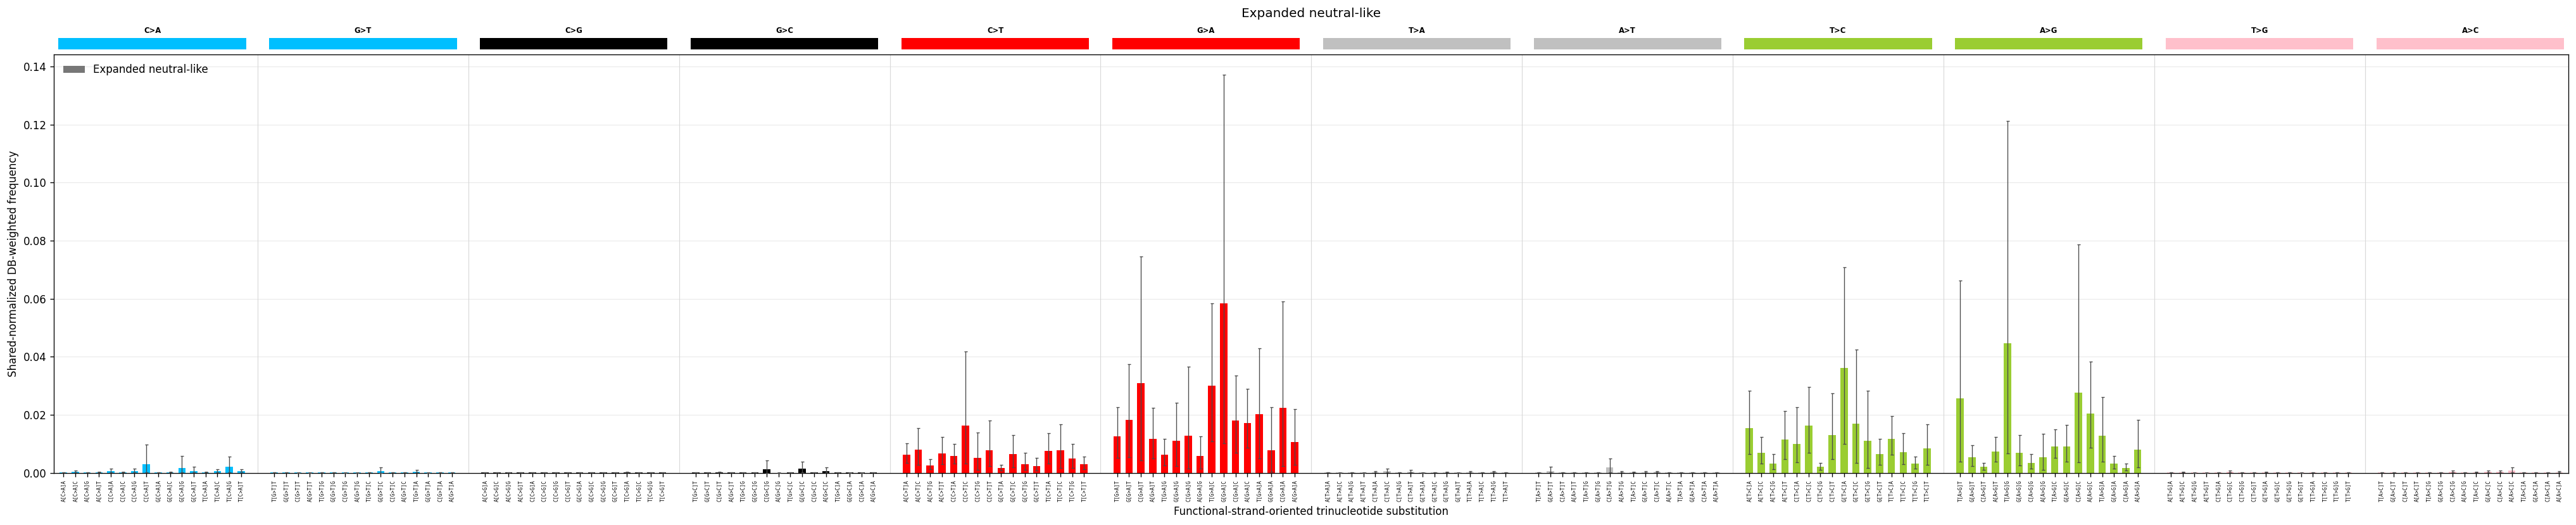

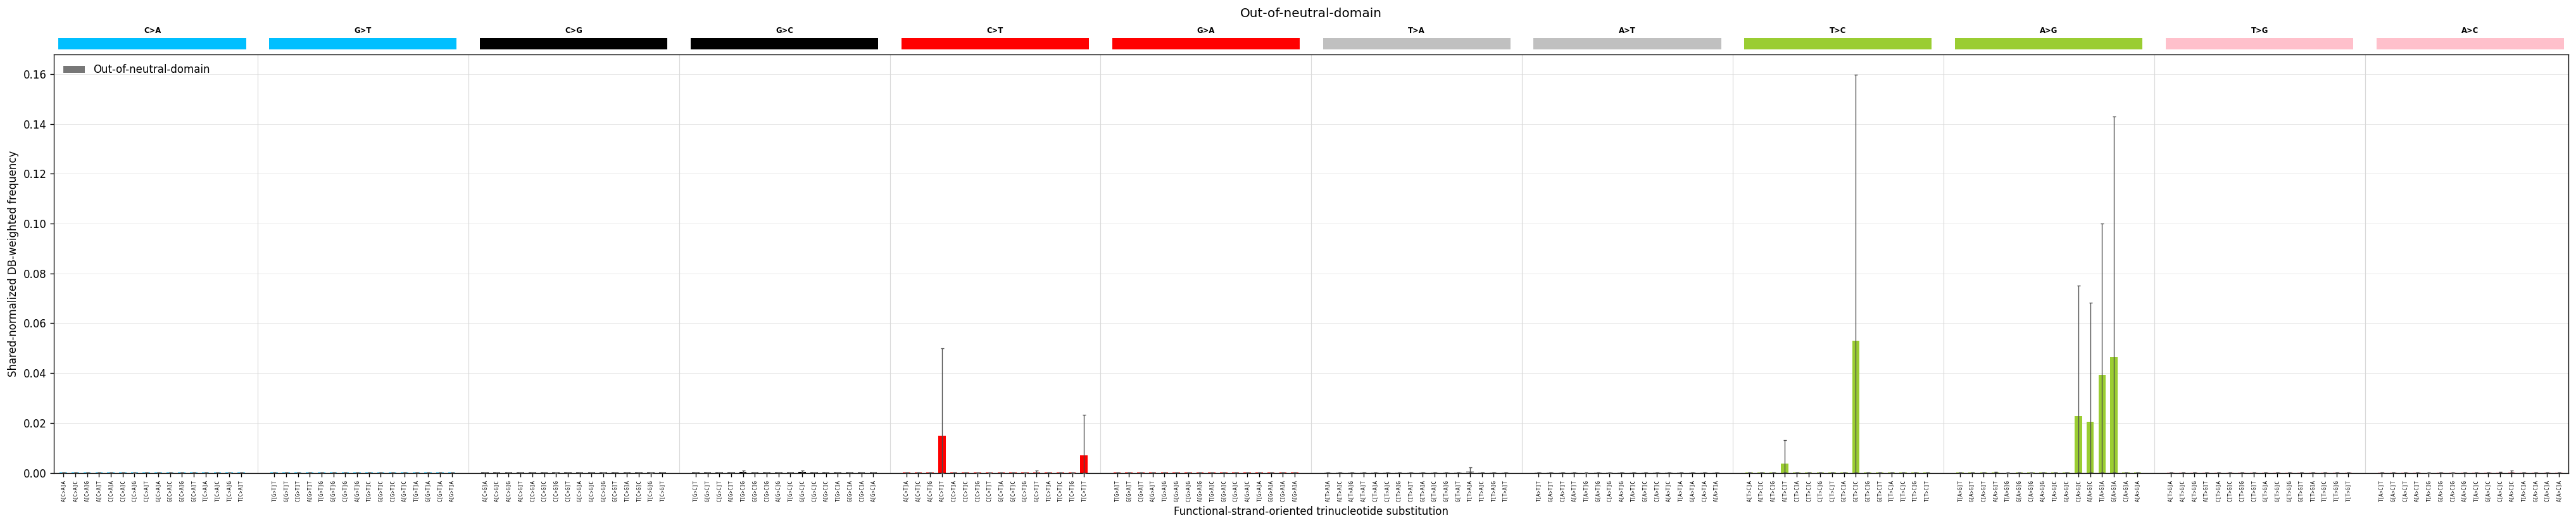

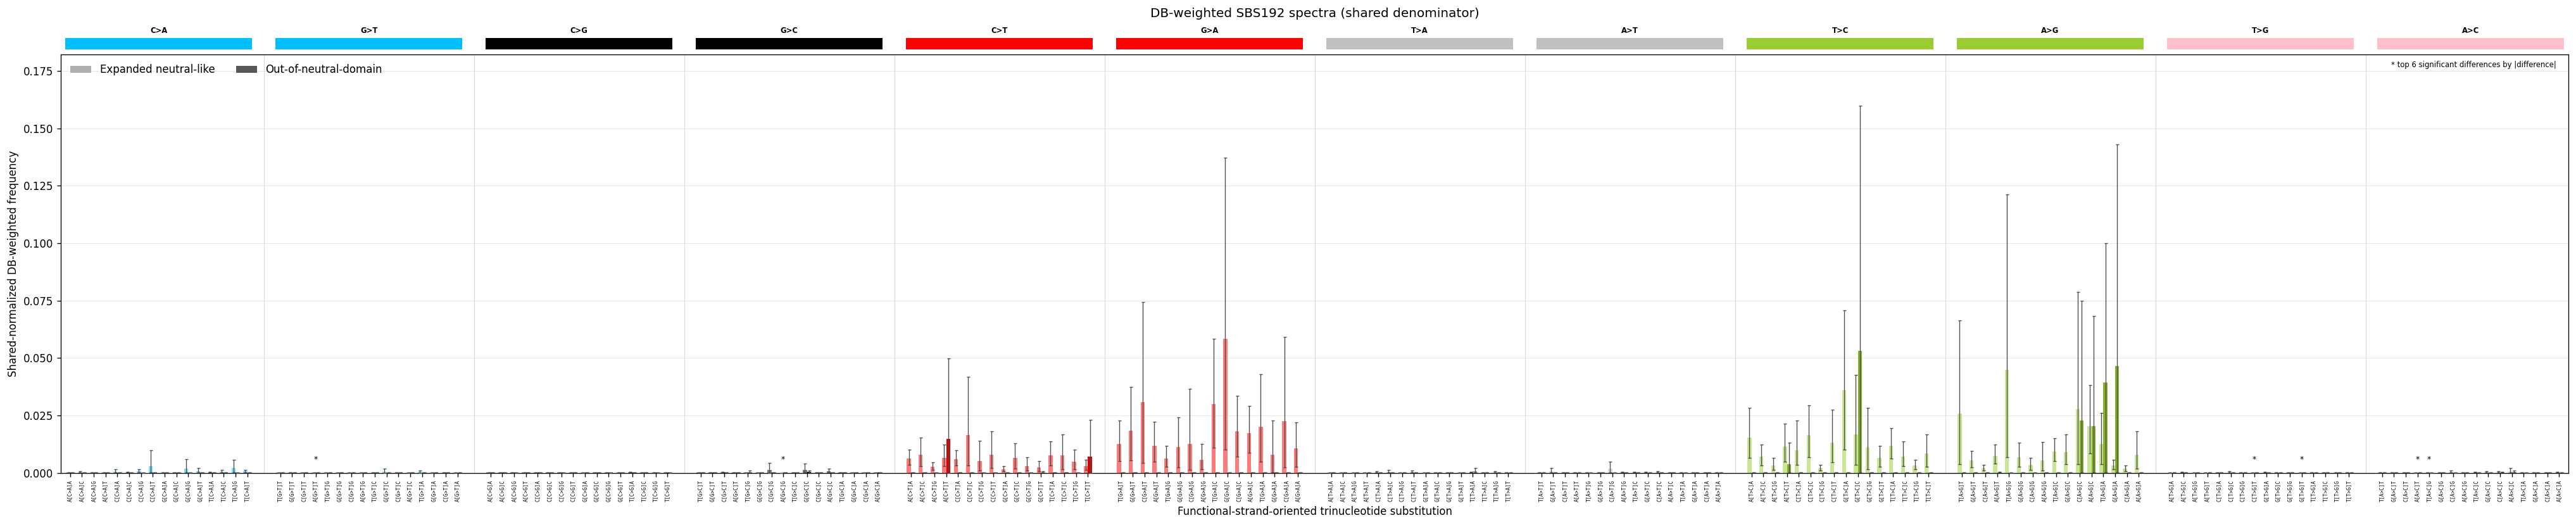

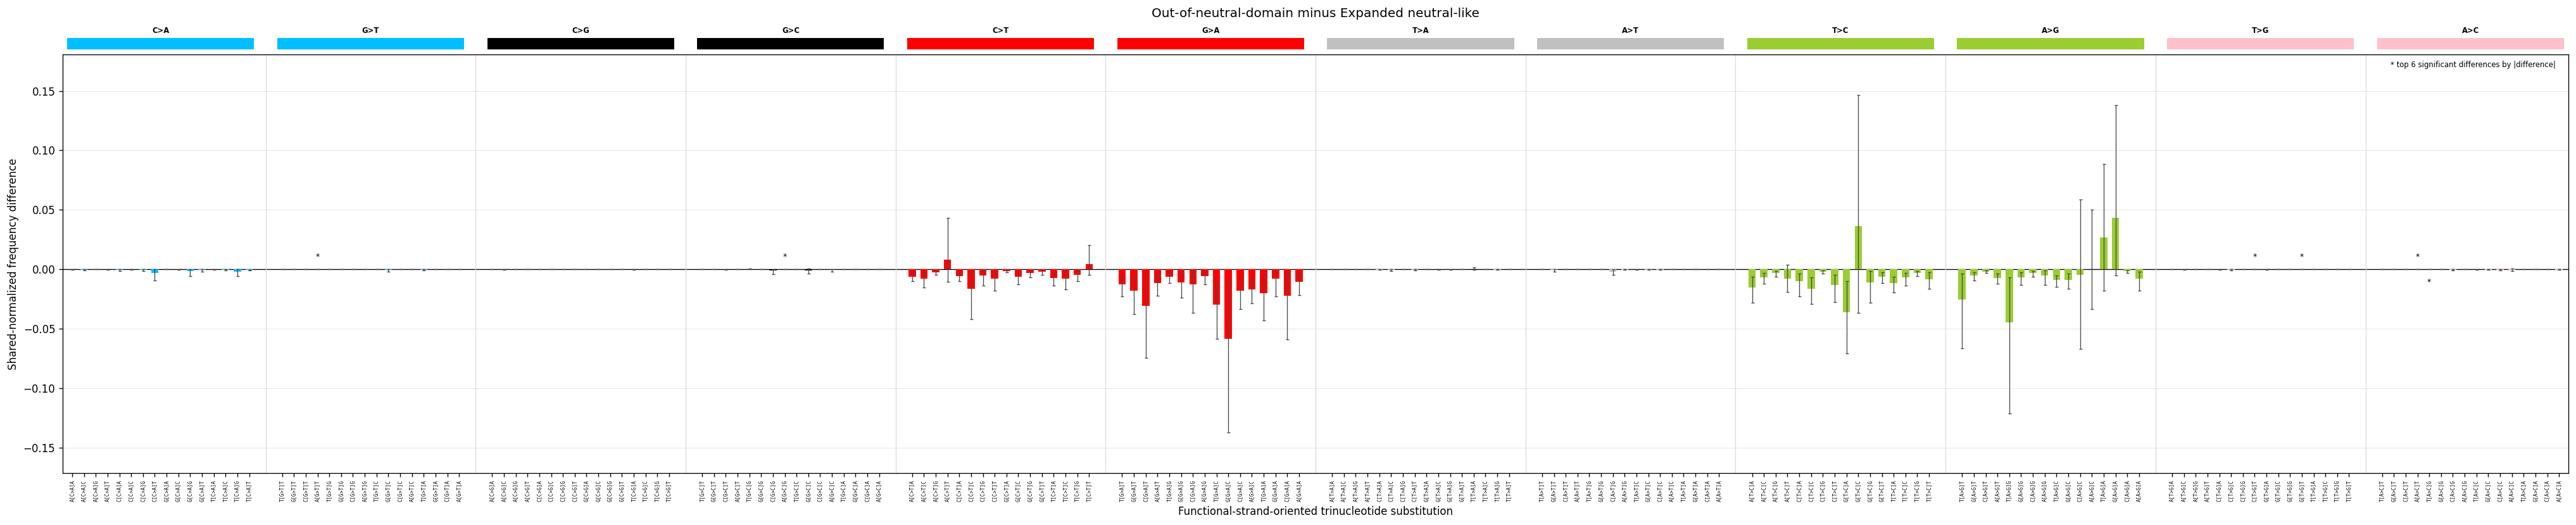

In [7]:
neutral_like_group, out_of_domain_group = GROUP_ORDER

for group_name in GROUP_ORDER:
    plot_mutspec192_with_ci(
        spectrum_uncertainty,
        group_order=[group_name],
        group_labels=group_label_map,
        group_col=GROUP_COL,
        category_col="substitution_type_192",
        title=group_label_map[group_name],
        ylabel="Shared-normalized DB-weighted frequency",
        output_path=(
            FIGURE_DIR / f"spectrum_{safe_filename(group_name)}.png"
        ),
    )

plot_mutspec192_with_ci(
    spectrum_uncertainty,
    group_order=GROUP_ORDER,
    group_labels=group_label_map,
    difference=spectrum_difference_uncertainty,
    group_col=GROUP_COL,
    category_col="substitution_type_192",
    title="DB-weighted SBS192 spectra (shared denominator)",
    ylabel="Shared-normalized DB-weighted frequency",
    output_path=(
        FIGURE_DIR
        / f"spectrum_comparison_{safe_filename(neutral_like_group)}_vs_{safe_filename(out_of_domain_group)}.png"
    ),
)

plot_mutspec192_difference_with_ci(
    spectrum_difference_uncertainty,
    category_col="substitution_type_192",
    title=(
        f"{group_label_map[out_of_domain_group]} minus "
        f"{group_label_map[neutral_like_group]}"
    ),
    output_path=(
        FIGURE_DIR
        / f"spectrum_difference_{safe_filename(out_of_domain_group)}_minus_{safe_filename(neutral_like_group)}.png"
    ),
)

print("Figures saved to:", FIGURE_DIR)